# Data visualization

In [1]:
%matplotlib inline

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
HELA_MS1_OUT_PATH = "../../data/PXD014777/processed/hela_ms1.csv"
HELA_MS2_OUT_PATH = "../../data/PXD014777/processed/hela_ms2.csv"
SPECIES_MS2_OUT_PATH = "../../data/PXD014777/processed/species_ms2.csv"

In [3]:
df_ms1_hela = pd.read_csv(HELA_MS1_OUT_PATH)
df_ms2_hela = pd.read_csv(HELA_MS2_OUT_PATH)
df_ms2_species = pd.read_csv(SPECIES_MS2_OUT_PATH)

/var/folders/dj/lbjr_33912s45mqrggv2hz9m0000gn/T/ipykernel_71833/1735780731.py:2: DtypeWarning: Columns (61,69) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ms2_hela = pd.read_csv(HELA_MS2_OUT_PATH)
/var/folders/dj/lbjr_33912s45mqrggv2hz9m0000gn/T/ipykernel_71833/1735780731.py:3: DtypeWarning: Columns (61,69) have mixed types. Specify dtype option on import or set low_memory=False.
  df_ms2_species = pd.read_csv(SPECIES_MS2_OUT_PATH)


## MS1 HeLa

Let's look at the distribution of the features.

In [4]:
features = [
    "Charge",
    "Mass",
    "m/z",
    "Retention time",
    "Retention length",
    "Ion mobility index",
    "Ion mobility length",
    "Number of isotopic peaks",
]

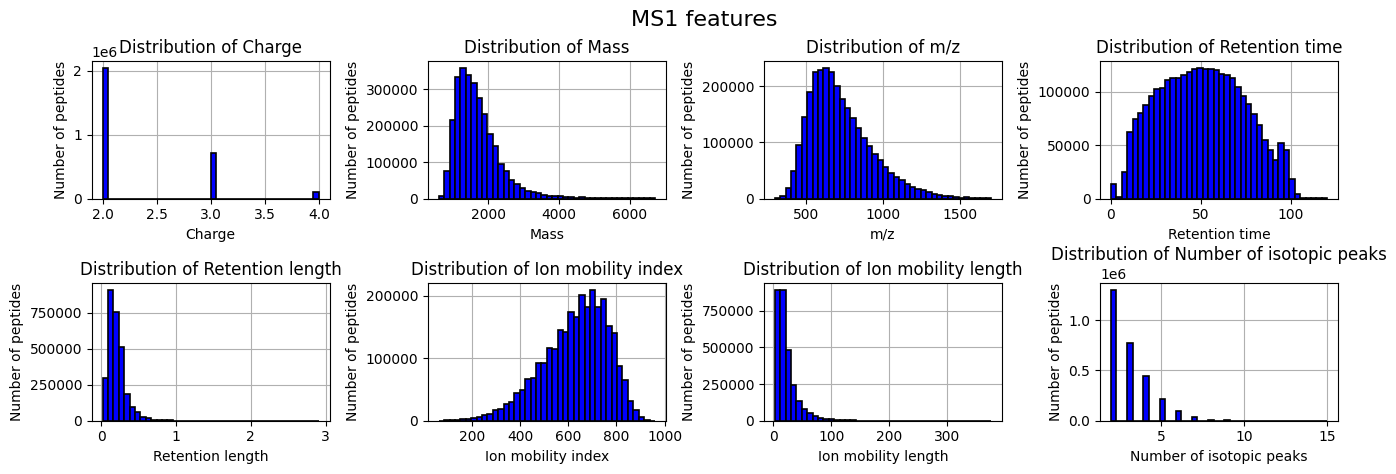

In [5]:
fig, axs = plt.subplots(figsize=(14, 5), ncols=4, nrows=2)
fig.tight_layout(pad=4.0)
fig.suptitle("MS1 features", fontsize=16)

for i, feature in enumerate(features):
    ax = axs[i // 4][i % 4]
    ax.hist(
        df_ms1_hela[feature], bins=40, color="blue", edgecolor="black", linewidth=1.2
    )
    ax.set_xlabel(feature)
    ax.set_ylabel("Number of peptides")
    ax.set_title(f"Distribution of {feature}")
    ax.grid(True)
    ax.set_axisbelow(True)

## MS2 HeLa data

Let's see how many runs a peptide is present in.

In [6]:
peptide_abundances = df_ms2_hela["PrecursorID"].value_counts()

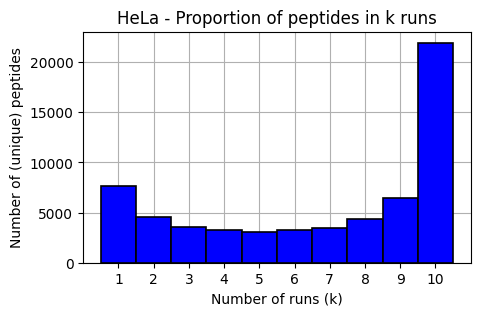

In [7]:
fig, ax = plt.subplots(figsize=(5, 3))
ax.hist(
    peptide_abundances,
    bins=range(1, np.max(peptide_abundances) + 2),
    color="blue",
    edgecolor="black",
    linewidth=1.2,
    align="left",
)
ax.set_xticks(range(1, np.max(peptide_abundances) + 1))
ax.set_title("HeLa - Proportion of peptides in k runs")
ax.set_xlabel("Number of runs (k)")
ax.set_ylabel("Number of (unique) peptides")
ax.grid(True)
ax.set_axisbelow(True)

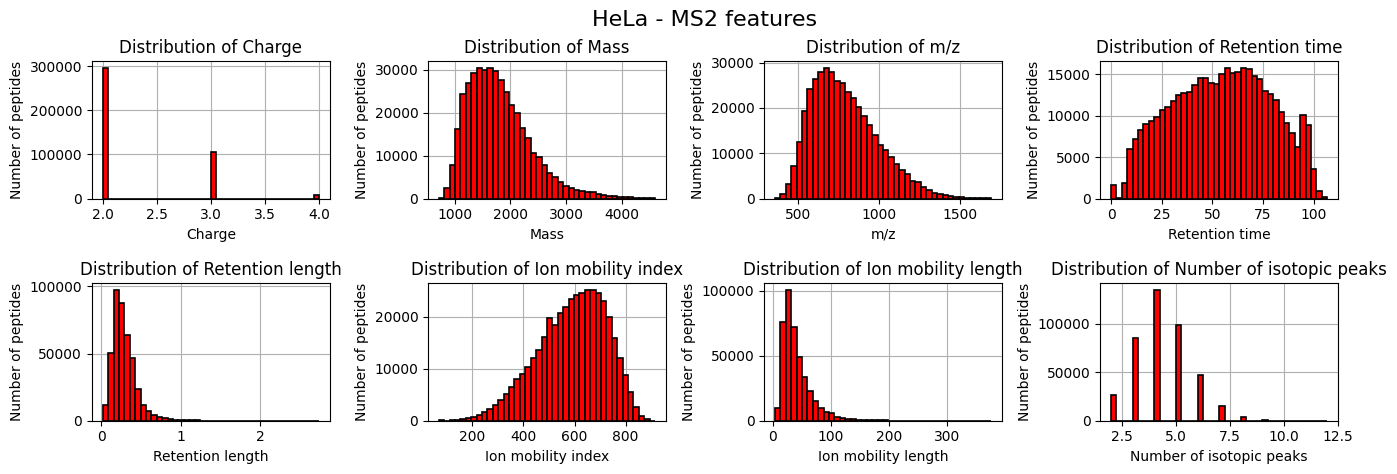

In [8]:
fig, axs = plt.subplots(figsize=(14, 5), ncols=4, nrows=2)
fig.tight_layout(pad=4.0)
fig.suptitle("HeLa - MS2 features", fontsize=16)

for i, feature in enumerate(features):
    ax = axs[i // 4][i % 4]
    ax.hist(
        df_ms2_hela[feature], bins=40, color="red", edgecolor="black", linewidth=1.2
    )
    ax.set_xlabel(feature)
    ax.set_ylabel("Number of peptides")
    ax.set_title(f"Distribution of {feature}")
    ax.grid(True)
    ax.set_axisbelow(True)

## Species data

Let's see how many runs a peptide is present in.

In [9]:
peptide_abundances = df_ms2_species["PrecursorID"].value_counts()

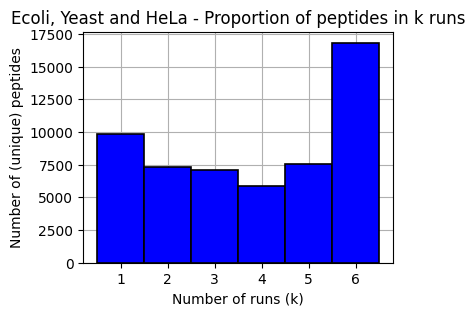

In [10]:
fig, ax = plt.subplots(figsize=(4, 3))
ax.hist(
    peptide_abundances,
    bins=range(1, np.max(peptide_abundances) + 2),
    color="blue",
    edgecolor="black",
    linewidth=1.2,
    align="left",
)
ax.set_xticks(range(1, np.max(peptide_abundances) + 1))
ax.set_title("Ecoli, Yeast and HeLa - Proportion of peptides in k runs")
ax.set_xlabel("Number of runs (k)")
ax.set_ylabel("Number of (unique) peptides")
ax.grid(True)
ax.set_axisbelow(True)

/var/folders/dj/lbjr_33912s45mqrggv2hz9m0000gn/T/ipykernel_71833/1379307063.py:37: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(


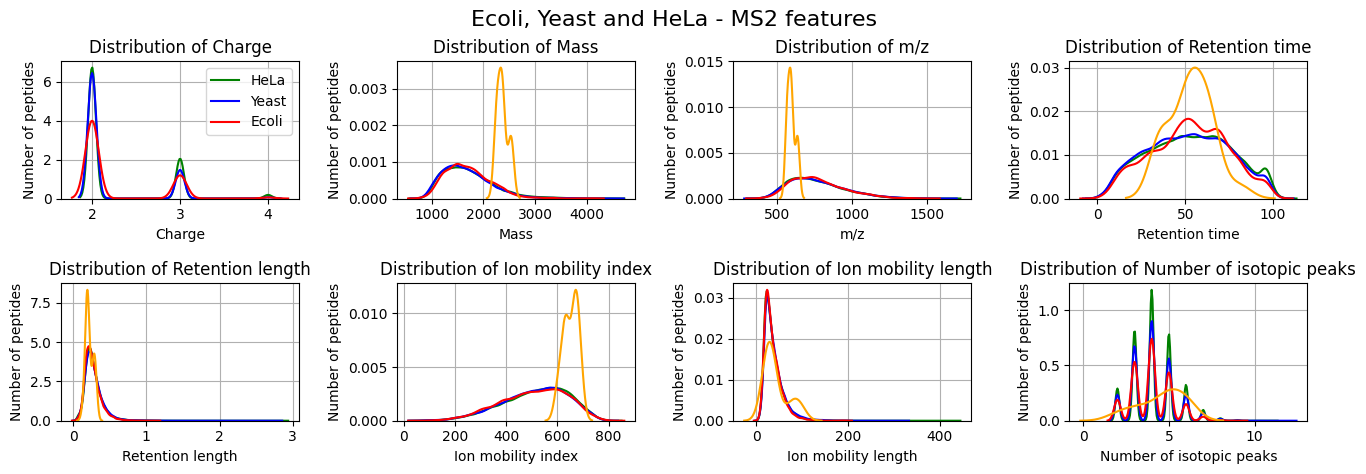

In [11]:
fig, axs = plt.subplots(figsize=(14, 5), ncols=4, nrows=2)
fig.tight_layout(pad=4.0)
fig.suptitle("Ecoli, Yeast and HeLa - MS2 features", fontsize=16)

yeast_filter = df_ms2_species["Species"] == "Yeast"
ecoli_filter = df_ms2_species["Species"] == "Ecoli"
hela_filter = df_ms2_species["Species"] == "HeLa"

problematic_sequences = [
    "LPYITFPEGSEEHTYLHAQR",
    "LSLTGGFSHHHATDDVEDAAPETK",
    "ILEVLQEPDNHHVSAEDLYK",
    "DVSLLHKPTTQISDFHVATR",
    "FGLPHADDVLGLPIGQHIVIK",
    "TLLEAIDAIEQPSRPTDKPLR",
]

# Extract problematic prototypes from ms2_species_data
problematic_prototypes_df = df_ms2_species[
    df_ms2_species["Sequence"].isin(problematic_sequences)
]
problematic_prototypes_df = problematic_prototypes_df[
    problematic_prototypes_df["Charge"] == 4
]

for i, feature in enumerate(features):
    ax = axs[i // 4][i % 4]
    sns.kdeplot(
        df_ms2_species[hela_filter][feature], color="green", label="HeLa", ax=ax
    )
    sns.kdeplot(
        df_ms2_species[yeast_filter][feature], color="blue", label="Yeast", ax=ax
    )
    sns.kdeplot(
        df_ms2_species[ecoli_filter][feature], color="red", label="Ecoli", ax=ax
    )
    sns.kdeplot(
        problematic_prototypes_df[feature], color="orange", label="Problematic", ax=ax
    )
    ax.set_xlabel(feature)
    ax.set_ylabel("Number of peptides")
    ax.set_title(f"Distribution of {feature}")
    ax.grid(True)
    ax.set_axisbelow(True)

axs[0][0].legend()

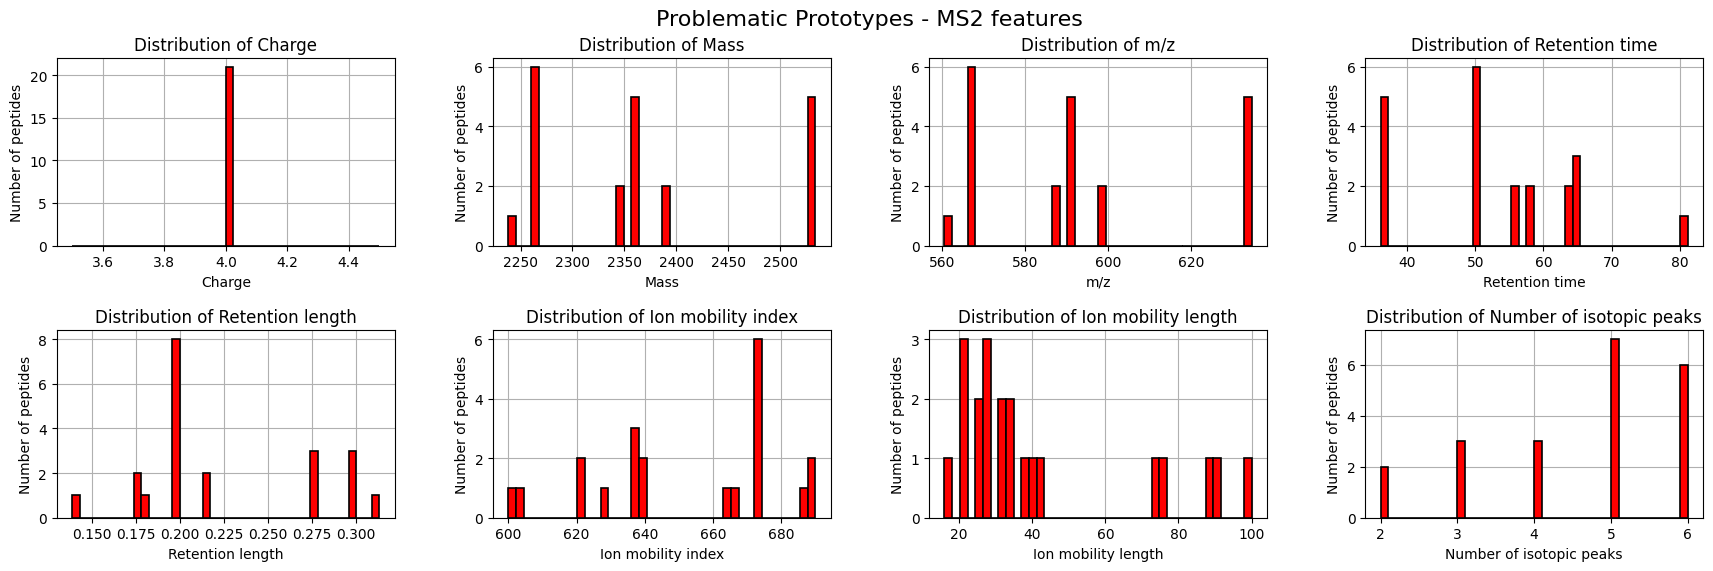

In [12]:
# Compare distribution of Yeast/Ecoli MS2 prototypes with problematic prototypes:
problematic_prototypes = [
    "Ecoli_LPYITFPEGSEEHTYLHAQR_4",
    "Yeast_LSLTGGFSHHHATDDVEDAAPETK_4",
    "Ecoli_ILEVLQEPDNHHVSAEDLYK_4",
    "Ecoli_DVSLLHKPTTQISDFHVATR_4",
    "Yeast_FGLPHADDVLGLPIGQHIVIK_4",
    "Yeast_TLLEAIDAIEQPSRPTDKPLR_4",
]

problematic_sequences = [
    "LPYITFPEGSEEHTYLHAQR",
    "LSLTGGFSHHHATDDVEDAAPETK",
    "ILEVLQEPDNHHVSAEDLYK",
    "DVSLLHKPTTQISDFHVATR",
    "FGLPHADDVLGLPIGQHIVIK",
    "TLLEAIDAIEQPSRPTDKPLR",
]

# Extract problematic prototypes from ms2_species_data
problematic_prototypes_df = df_ms2_species[
    df_ms2_species["Sequence"].isin(problematic_sequences)
]
problematic_prototypes_df = problematic_prototypes_df[
    problematic_prototypes_df["Charge"] == 4
]

fig, axs = plt.subplots(figsize=(18, 6), ncols=4, nrows=2)
fig.tight_layout(pad=4.0)
fig.suptitle("Problematic Prototypes - MS2 features", fontsize=16)

for i, feature in enumerate(features):
    ax = axs[i // 4][i % 4]
    ax.hist(
        problematic_prototypes_df[feature],
        bins=40,
        color="red",
        edgecolor="black",
        linewidth=1.2,
    )
    ax.set_xlabel(feature)
    ax.set_ylabel("Number of peptides")
    ax.set_title(f"Distribution of {feature}")
    ax.grid(True)
    ax.set_axisbelow(True)